<a href="https://colab.research.google.com/github/hayajahan07/ACMRecruitment-hayajahan07/blob/main/questline-2/2-draw-the-line/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

No csv found - creating sample house data
   Area          Price
0  1360  241463.683841
1  1794  315732.453788
2  1630  291329.969903
3  1595  281899.933917
4  2138  334485.023297

3a - Train: 80 records (80%) | Test: 20 records (20%)
This prevents data leakage - model learns on 80%, tested on unseen 20%

3b - Linear Regression Trained
Equation: Price = 148.76 * Area + 23059.87
Coefficient (slope) = 148.76
Intercept = 23059.87


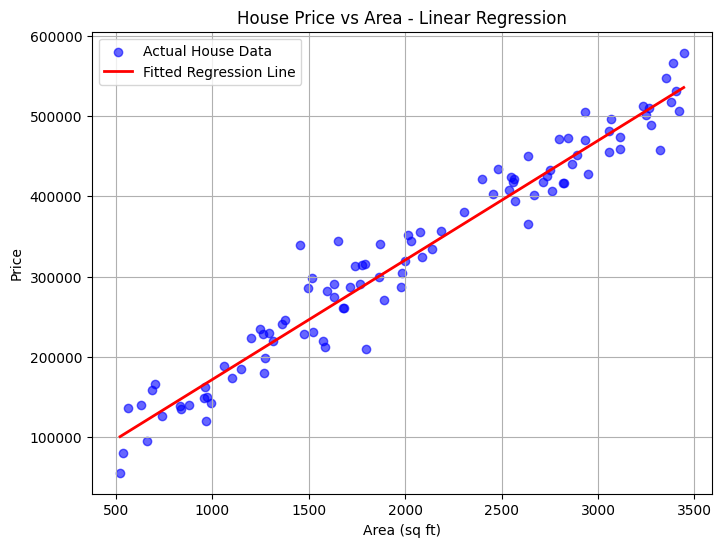


3d - Manual Calculation:
MSE (manual) = 821156269.49
R2 (manual) = 0.9441

Verification with sklearn:
MSE (sklearn) = 821156269.49
R2 (sklearn) = 0.9441

Match? MSE same: True | R2 same: True


In [1]:
# Quest 3 - Draw the Line - Full Solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Load Data ---
# If you have house_data.csv upload it, else this synthetic will run
try:
    df = pd.read_csv('house_data.csv')
    # auto-detect columns
    if 'Area' not in df.columns:
        df.columns = ['Area','Price'] # if no header
except:
    print("No csv found - creating sample house data")
    np.random.seed(42)
    Area = np.random.randint(500, 3500, 100)
    Price = 150 * Area + 20000 + np.random.normal(0, 30000, 100)
    df = pd.DataFrame({'Area': Area, 'Price': Price})

print(df.head())

# --- 3a Enter the Marketplace ---
# Separate X and y, 80% train 20% test
X = df[['Area']] # 2D for sklearn
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n3a - Train: {X_train.shape[0]} records (80%) | Test: {X_test.shape[0]} records (20%)")
print("This prevents data leakage - model learns on 80%, tested on unseen 20%")

# --- 3b Forge the Prediction Line ---
model = LinearRegression()
model.fit(X_train, y_train)

coef = model.coef_[0]
intercept = model.intercept_

print(f"\n3b - Linear Regression Trained")
print(f"Equation: Price = {coef:.2f} * Area + {intercept:.2f}")
print(f"Coefficient (slope) = {coef:.2f}")
print(f"Intercept = {intercept:.2f}")

# --- 3c Reveal the Hidden Pattern ---
y_pred_test = model.predict(X_test)
y_pred_train_line = model.predict(X) # for smooth line, sort by Area

plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual House Data')
# Sort for clean line
sorted_idx = X['Area'].argsort()
plt.plot(X['Area'].iloc[sorted_idx], y_pred_train_line[sorted_idx], color='red', linewidth=2, label='Fitted Regression Line')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.title('House Price vs Area - Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

# --- 3d Challenge the Oracle ---
# MANUAL CALCULATION
# MSE = mean( (y_true - y_pred)^2 )
# R2 = 1 - SS_res / SS_tot

y_true = y_test.values
y_pred = y_pred_test

# MSE manual
mse_manual = np.mean((y_true - y_pred)**2)

# R2 manual
ss_res = np.sum((y_true - y_pred)**2)
ss_tot = np.sum((y_true - np.mean(y_true))**2)
r2_manual = 1 - (ss_res / ss_tot)

print(f"\n3d - Manual Calculation:")
print(f"MSE (manual) = {mse_manual:.2f}")
print(f"R2 (manual) = {r2_manual:.4f}")

# SKLEARN VERIFICATION
mse_sklearn = mean_squared_error(y_true, y_pred)
r2_sklearn = r2_score(y_true, y_pred)

print(f"\nVerification with sklearn:")
print(f"MSE (sklearn) = {mse_sklearn:.2f}")
print(f"R2 (sklearn) = {r2_sklearn:.4f}")

print(f"\nMatch? MSE same: {np.isclose(mse_manual, mse_sklearn)} | R2 same: {np.isclose(r2_manual, r2_sklearn)}")